In [1]:
import numpy as np
import MDAnalysis as mda
from MDAnalysis.analysis import rdf, msd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.spatial.distance import pdist, squareform
import collections
from MDAnalysis.lib.distances import distance_array
plt.style.use("default")

In [2]:
#load data
u = mda.Universe(
    "system2000.data",
    "2000_2ns.lammpstrj.gz",
    topology_format="DATA",
    format="LAMMPSDUMP"
)

E:\ACS\GRA\Research\proton-project\.venv\Lib\site-packages\MDAnalysis\coordinates\LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


In [3]:
#set timestep
timestep_fs = 1.0
dump_stride = 100
dt_ps = timestep_fs * dump_stride / 1000.0  # 1 ps per frame

In [4]:
#check time for frame
frame_idx = 10
frame_time = u.trajectory[frame_idx].frame * dt_ps
print(frame_time)  # 1 ps

1.0


In [5]:
print(u)
print(u.atoms.n_atoms)
print(len(u.trajectory))

<Universe with 17000 atoms>
17000
2000


In [6]:
print(u.atoms.types[:10])
print(u.atoms.positions[:5])

['4' '7' '2' '3' '3' '1' '3' '7' '4' '2']
[[26.172544   4.985836  22.044544 ]
 [26.992605   5.0042343 21.536224 ]
 [26.885904   3.9372346 20.638895 ]
 [25.97715    3.9526346 20.017506 ]
 [26.880037   2.9869344 21.194836 ]]


In [7]:
Ow = u.select_atoms("type 6")
Hw = u.select_atoms("type 5")
Og = u.select_atoms("type 7")
Hg = u.select_atoms("type 4")

In [8]:
#Radial Distribution Function - water oxygens
rdf_OwOw = rdf.InterRDF(Ow, Ow, range=(0, 10), nbins=200)
rdf_OwOw.run()

#3h 14m

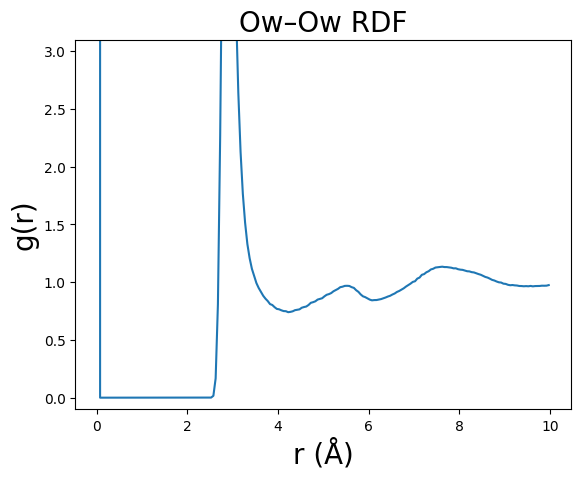

In [37]:
plt.plot(rdf_OwOw.results.bins, rdf_OwOw.results.rdf)
plt.xlabel("r (Å)", fontsize=20)
plt.ylabel("g(r)", fontsize=20)
plt.title("Ow–Ow RDF", fontsize=20)
plt.ylim(-0.1, 3.1)
plt.savefig("figures/2ns/OwOw-rdf.png", format="png", )
plt.show()

In [10]:
#Radial Distribution Function - glycerol oxygens
rdf_OgOg = rdf.InterRDF(Og, Og, range=(0, 10), nbins=200)
rdf_OgOg.run()

#3h 21m

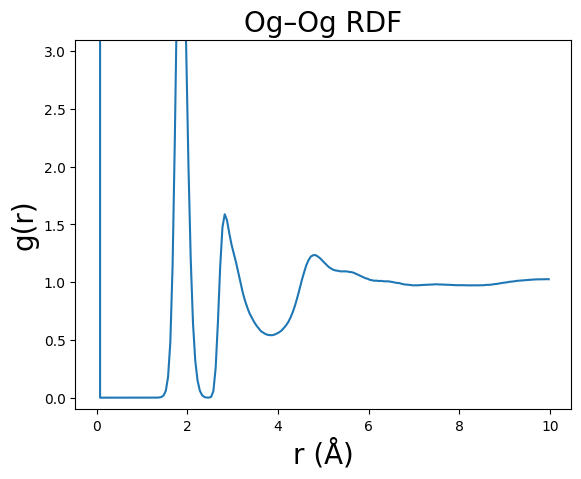

In [38]:
plt.plot(rdf_OgOg.results.bins, rdf_OgOg.results.rdf)
plt.xlabel("r (Å)", fontsize=20)
plt.ylabel("g(r)", fontsize=20)
plt.title("Og–Og RDF", fontsize=20)
plt.ylim(-0.1, 3.1)
plt.savefig("figures/2ns/OgOg-rdf.png", format="png", )
plt.show()

In [12]:
#Radial Distribution Function - water to glycerol oxygens
rdf_OwOg = rdf.InterRDF(Ow, Og, range=(0, 10), nbins=200)
rdf_OwOg.run()

#3h 17m

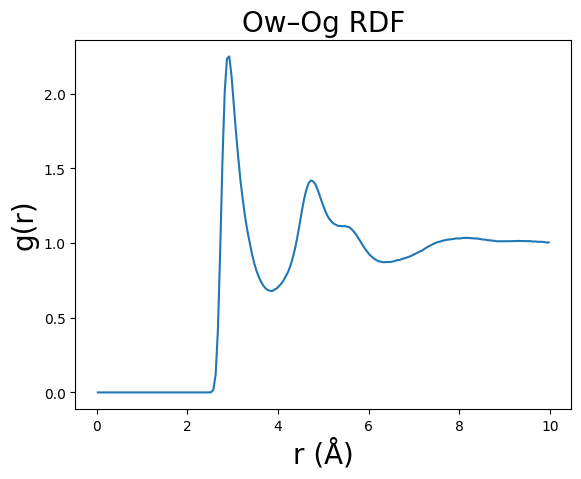

In [39]:
plt.plot(rdf_OwOg.results.bins, rdf_OwOg.results.rdf)
plt.xlabel("r (Å)", fontsize=20)
plt.ylabel("g(r)", fontsize=20)
plt.title("Ow–Og RDF", fontsize=20)
plt.savefig("figures/2ns/OwOg-rdf.png", format="png", )
plt.show()

In [14]:
#Radial Distribution Function - glycerol to water oxygens
rdf_OgOw = rdf.InterRDF(Og, Ow, range=(0, 10), nbins=200)
rdf_OgOw.run()

#3h 26m

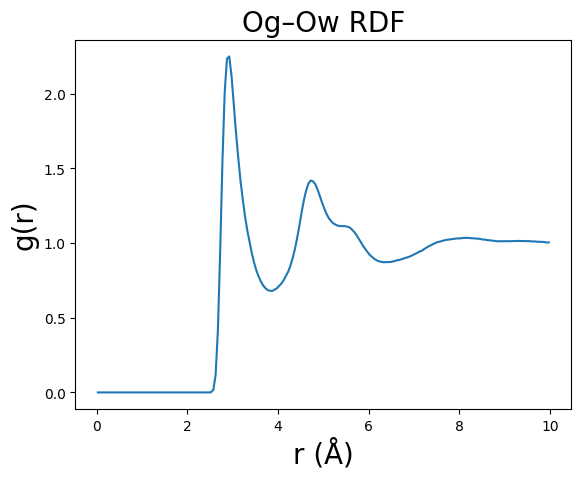

In [40]:
plt.plot(rdf_OwOg.results.bins, rdf_OwOg.results.rdf)
plt.xlabel("r (Å)", fontsize=20)
plt.ylabel("g(r)", fontsize=20)
plt.title("Og–Ow RDF", fontsize=20)
plt.savefig("figures/2ns/OgOw-rdf.png", format="png", )
plt.show()

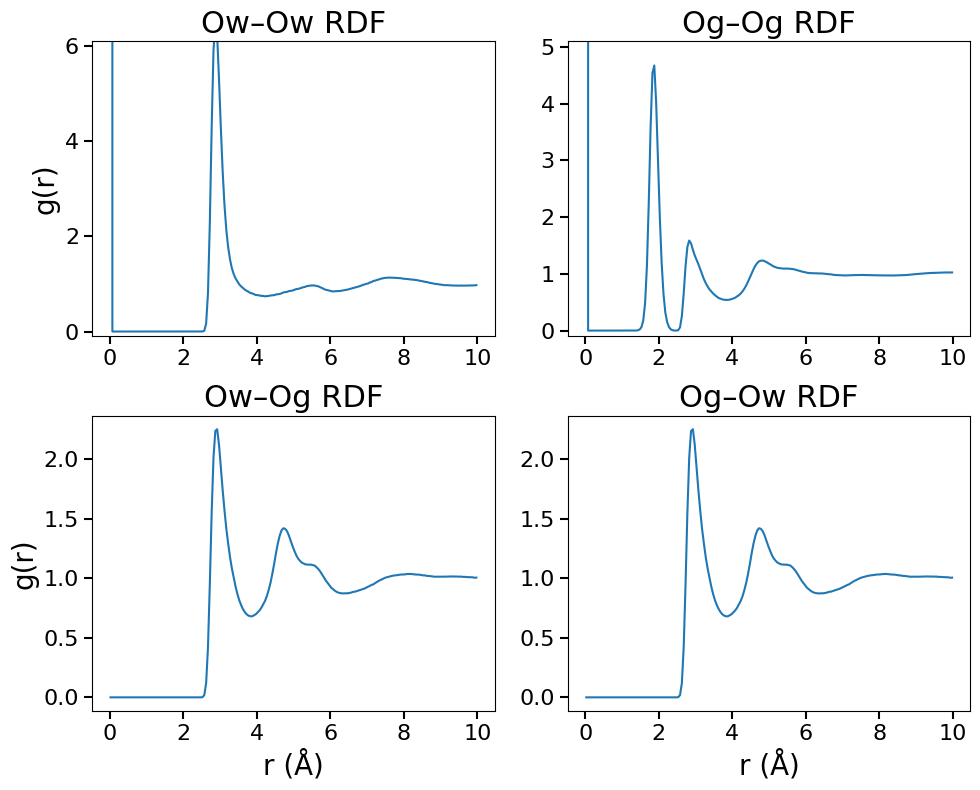

In [48]:
# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Ow–Ow
axes[0,0].plot(rdf_OwOw.results.bins, rdf_OwOw.results.rdf)
axes[0,0].set_title("Ow–Ow RDF", fontsize=22)
axes[0,0].set_ylim(-0.1, 6.1)
axes[0,0].tick_params(axis="both", labelsize=16, length=6, width=1.5)

# Og–Og
axes[0,1].plot(rdf_OgOg.results.bins, rdf_OgOg.results.rdf)
axes[0,1].set_title("Og–Og RDF", fontsize=22)
axes[0,1].set_ylim(-0.1, 5.1)
axes[0,1].tick_params(axis="both", labelsize=16, length=6, width=1.5)

# Ow–Og
axes[1,0].plot(rdf_OwOg.results.bins, rdf_OwOg.results.rdf)
axes[1,0].set_title("Ow–Og RDF", fontsize=22)
axes[1,0].tick_params(axis="both", labelsize=16, length=6, width=1.5)

# Og–Ow
axes[1,1].plot(rdf_OgOw.results.bins, rdf_OgOw.results.rdf)
axes[1,1].set_title("Og–Ow RDF", fontsize=22)
axes[1,1].tick_params(axis="both", labelsize=16, length=6, width=1.5)

# Only label left and bottom
axes[1,0].set_xlabel("r (Å)", fontsize=20)
axes[1,1].set_xlabel("r (Å)", fontsize=20)
axes[0,0].set_ylabel("g(r)", fontsize=20)
axes[1,0].set_ylabel("g(r)", fontsize=20)

for ax in axes[0, :]:
    ax.set_xlabel("")
for ax in axes[:, 1]:
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig("figures/2ns/rdf-all.png", format="png", )
plt.show()

In [16]:
#Coordination Numbers
def coordination_number(r, g_r, rho, r_cut):
    mask = r <= r_cut
    integrand = 4 * np.pi * rho * g_r[mask] * r[mask]**2
    return np.trapezoid(integrand, r[mask])

In [17]:
# number density of oxygens
rho_Ow = Ow.n_atoms / np.prod(u.dimensions[:3])
rho_Og = Og.n_atoms / np.prod(u.dimensions[:3])

# find first minimum manually (example value!)
r_cut = 3.4  # Å

#Coordination number for water oxygens
CN_OwOw = coordination_number(
    rdf_OwOw.results.bins,
    rdf_OwOw.rdf,
    rho_Ow,
    r_cut
)

#Coordination number for glycerol oxygens
CN_OgOg = coordination_number(
    rdf_OgOg.results.bins,
    rdf_OgOg.rdf,
    rho_Og,
    r_cut
)

#Coordination number for glycerol oxygens to water oxygens
CN_OwOg = coordination_number(
    rdf_OwOg.results.bins,
    rdf_OwOg.rdf,
    rho_Og,
    r_cut
)

#Coordination number for water oxygens to glycerol oxygens
CN_OgOw = coordination_number(
    rdf_OwOg.results.bins,
    rdf_OwOg.rdf,
    rho_Ow,
    r_cut
)

print("Ow–Ow coordination number:", CN_OwOw)
print("Og-Og coordination number:", CN_OgOg)
print("Ow-Og coordination number:", CN_OwOg)
print("Og-Ow coordination number:", CN_OgOw)

Ow–Ow coordination number: 2.2822896242744517
Og-Og coordination number: 3.6915008136538776
Ow-Og coordination number: 2.6836235859355693
Og-Ow coordination number: 0.8945412204841259


In [18]:
#Coordination Distribution
cutoff = 3.5  # Å

coord_numbers = []

for ts in u.trajectory:
    dists = distance_array(
        Ow.positions,
        Og.positions,
        box=u.dimensions
    )
    counts = np.sum(dists < cutoff, axis=1)
    coord_numbers.extend(counts)

#3m 35s

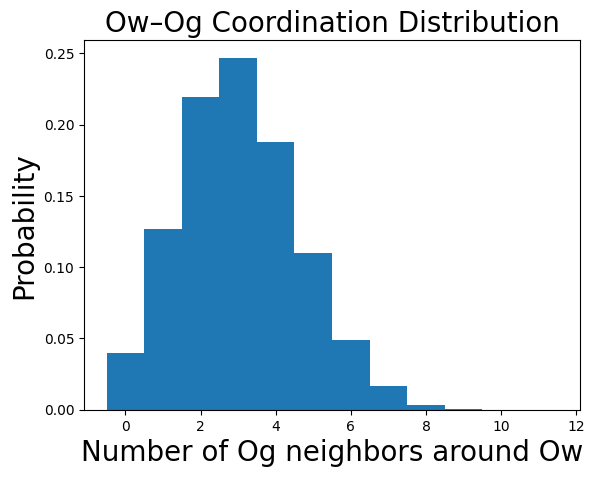

In [19]:
plt.hist(coord_numbers, bins=np.arange(0, max(coord_numbers)+2)-0.5, density=True)
plt.xlabel("Number of Og neighbors around Ow", fontsize=20)
plt.ylabel("Probability", fontsize=20)
plt.title("Ow–Og Coordination Distribution", fontsize=20)
plt.savefig("figures/2ns/OwOg-Coordination.png", format="png", )
plt.show()


In [20]:
water_residues = []
glycerol_residues = []

for res in u.residues:
    types = set(res.atoms.types)

    if types.issubset({"5", "6"}):        # water (Hw, Ow)
        water_residues.append(res)
    elif types.issubset({"1", "2", "3", "4", "7"}):      # glycerol (Hg, Og)
        glycerol_residues.append(res)

In [21]:
print("Water residues:", len(water_residues))
print("Glycerol residues:", len(glycerol_residues))

print("Atoms per water residue:",
      set(len(res.atoms) for res in water_residues[:10]))
print("Atoms per glycerol residue:",
      set(len(res.atoms) for res in glycerol_residues[:10]))

Water residues: 1000
Glycerol residues: 1000
Atoms per water residue: {3}
Atoms per glycerol residue: {14}


In [22]:
water_com = np.array([res.atoms.center_of_mass() for res in water_residues])
glycerol_com = np.array([res.atoms.center_of_mass() for res in glycerol_residues])

In [23]:
#Cluster analysis
cutoff = 6.5  # Å

dist_matrix = squareform(pdist(glycerol_com))
adjacency = dist_matrix < cutoff
np.fill_diagonal(adjacency, False)

G = nx.from_numpy_array(adjacency)
clusters = list(nx.connected_components(G))
cluster_sizes = [len(c) for c in clusters]

size_counts = collections.Counter(cluster_sizes)
sizes, counts = zip(*sorted(size_counts.items()))

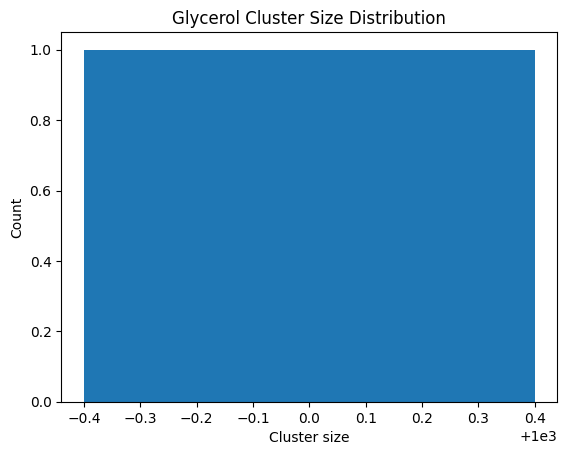

In [24]:
plt.bar(sizes, counts)
plt.xlabel("Cluster size")
plt.ylabel("Count")
plt.title("Glycerol Cluster Size Distribution")
plt.show()

In [25]:
#MSD and Diffusion
msd_water = msd.EinsteinMSD(u, select="type 6", msd_type="xyz")
msd_water.run()
print(msd_water.results.keys())

#3h 5m

100%|██████████| 1000/1000 [00:00<00:00, 2036.81it/s]

KeysView({'msds_by_particle': array([[ 0.00000000e+00, -1.86264515e-09, -2.32830644e-10, ...,
        -1.86264515e-09, -5.58793545e-09, -3.72529030e-09],
       [ 4.22923339e-01,  4.02770527e-01,  3.54672981e-01, ...,
         3.50976957e-01,  3.92878613e-01,  4.65793021e-01],
       [ 4.44045011e-01,  4.02664965e-01,  3.65177127e-01, ...,
         3.59568647e-01,  4.05905248e-01,  4.79257935e-01],
       ...,
       [ 8.51463678e+00,  2.98386477e+00,  3.22560337e+00, ...,
         1.41019012e+01,  1.15860347e+00,  3.35845625e+00],
       [ 8.86895825e+00,  2.92003601e+00,  4.08101723e+00, ...,
         1.58402664e+01,  5.92528231e-01,  3.89911149e+00],
       [ 7.48770991e+00,  3.73428061e+00,  2.97115011e+00, ...,
         1.85609213e+01,  5.22868778e-02,  4.05018688e+00]],
      shape=(2000, 1000)), 'timeseries': array([-1.93991582e-09,  4.55849043e+01,  4.65955037e+01, ...,
        1.98823831e+02,  1.91976919e+02,  1.97314287e+02], shape=(2000,)), 'delta_t_values': array([0.000e+00

In [26]:
# Mean Squared Displacement (MSD)
msd_vals = msd_water.results.timeseries

# time axis (ps)
time = np.arange(len(msd_vals)) * dt_ps

print(time[:5])
print(time[-1])

[0.  0.1 0.2 0.3 0.4]
199.9


In [27]:
print(type(msd_water.results.timeseries))
print(msd_water.results.timeseries.shape)
print(msd_water.results.timeseries[:10])

<class 'numpy.ndarray'>
(2000,)
[-1.93991582e-09  4.55849043e+01  4.65955037e+01  4.66536800e+01
  4.72211953e+01  4.78166625e+01  4.86553009e+01  4.89246604e+01
  4.90309685e+01  4.95344998e+01]


In [28]:
print("dt_ps =", dt_ps)
print("time[0:5] =", time[:5])
print("time[-1] =", time[-1])

dt_ps = 0.1
time[0:5] = [0.  0.1 0.2 0.3 0.4]
time[-1] = 199.9


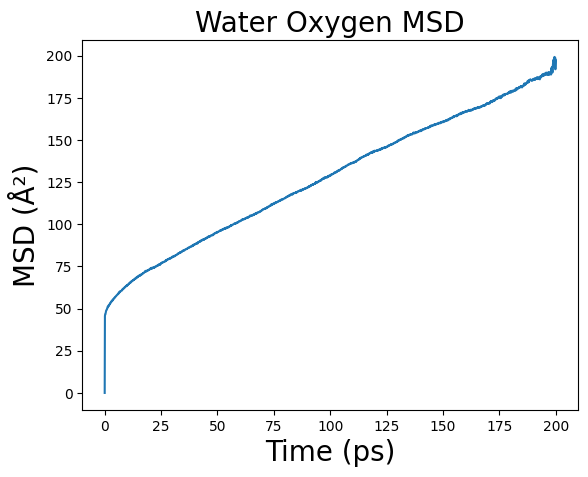

In [29]:
plt.plot(time, msd_vals)
plt.xlabel("Time (ps)", fontsize=20)
plt.ylabel("MSD (Å²)", fontsize=20)
plt.title("Water Oxygen MSD", fontsize=20)
plt.savefig("figures/2ns/Ow-msd.png", format="png", )
plt.show()

In [30]:
fit_start = int(0.7 * len(time))
slope, _ = np.polyfit(time[fit_start:], msd_vals[fit_start:], 1)

D_water = slope / 6.0
print("Water diffusion coefficient (Å²/ps):", D_water)

Water diffusion coefficient (Å²/ps): 0.10308358267396334


In [31]:
n_atoms_per_gly = 7
n_gly = len(Og) // 1

glycerol_groups = [
    u.select_atoms(f"bynum {i}-{i+n_atoms_per_gly-1}")
    for i in range(1, len(u.atoms)+1, n_atoms_per_gly)
]

In [32]:
# Compute COM trajectory
glycerol_com_traj = []
for ts in u.trajectory:
    coms = np.array([grp.center_of_mass() for grp in glycerol_groups])
    glycerol_com_traj.append(coms)

glycerol_com_traj = np.array(glycerol_com_traj)  # shape (T, N_mol, 3)

In [33]:
# Compute MSD
def com_msd(positions):
    r0 = positions[0]
    disp = positions - r0
    return np.mean(np.sum(disp**2, axis=2), axis=1)

msd_gly = com_msd(glycerol_com_traj)
time_gly = np.arange(len(msd_gly)) * dt_ps

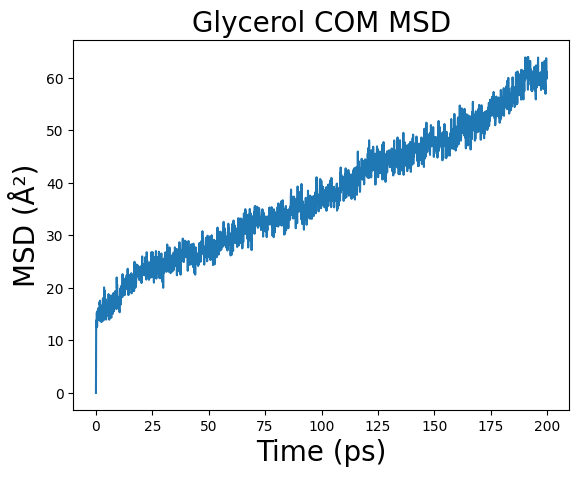

In [34]:
plt.figure()
plt.plot(time_gly, msd_gly)
plt.xlabel("Time (ps)", fontsize=20)
plt.ylabel("MSD (Å²)", fontsize=20)
plt.title("Glycerol COM MSD", fontsize=20)
plt.savefig("figures/2ns/Og-msd.png", format="png", )
plt.show()

In [35]:
fit_start = int(0.2 * len(time_gly))
slope, _ = np.polyfit(time_gly[fit_start:], msd_gly[fit_start:], 1)
D_gly = slope / 6.0
print("Glycerol diffusion coefficient (Å²/ps):", D_gly)

Glycerol diffusion coefficient (Å²/ps): 0.03553500194041527


In [36]:
u.trajectory[0].has_velocities

True